## AGN Homework 2 – Galaxy Classification

In [1]:
%%capture

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from astroquery.sdss import SDSS

from astropy.io import fits

In [2]:
sql = '''SELECT 
 oiii_5007_flux, nii_6584_flux, h_beta_flux, h_alpha_flux,
 (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
 (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio,
 s.class,
 s.subclass
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
 AND s.snmedian_g > 40
 AND g.oiii_5007_eqw < 0
 AND g.nii_6584_eqw < 0
 AND g.h_beta_eqw < 0
 AND g.h_alpha_eqw < 0
 AND g.oiii_5007_flux > 5
 AND g.nii_6584_flux > 5
 AND g.h_beta_flux > 5
 AND g.h_alpha_flux > 5
 AND g.oiii_5007_flux > 5 * g.oiii_5007_flux_err
 AND g.nii_6584_flux > 5 * g.nii_6584_flux_err
 AND g.h_beta_flux > 5 * g.h_beta_flux_err
 AND g.h_alpha_flux > 5 * g.h_alpha_flux_err
 AND (2.355 * g.sigma_forbidden) < 500
 AND (2.355 * g.sigma_balmer) < 500'''

table = SDSS.query_sql(sql)

df_tab = table.to_pandas()
df_tab.to_csv('a_tab.csv', index=False)

print(f"found {len(df_tab)} objects with subclasses {', '.join(map(str, df_tab['subclass'].dropna().unique()))}\n")

df_tab.head(10).style.hide()

found 958 objects with subclasses STARBURST, BROADLINE, AGN BROADLINE, STARFORMING, AGN, STARFORMING BROADLINE, STARBURST BROADLINE



oiii_5007_flux,nii_6584_flux,h_beta_flux,h_alpha_flux,oiii_hbeta_ratio,nii_halpha_ratio,class,subclass
6074.062000,1743.394000,3250.791000,10285.940000,1.868487,0.169493,GALAXY,STARBURST
577.455300,2210.942000,1254.602000,4352.196000,0.460270,0.508006,GALAXY,STARBURST
114.492100,200.411300,68.511800,215.892800,1.671130,0.928291,GALAXY,BROADLINE
111.137600,128.614600,58.325860,161.072800,1.905460,0.798488,GALAXY,BROADLINE
278.627100,1349.898000,203.431300,859.090600,1.369637,1.571311,GALAXY,AGN BROADLINE
78.398930,155.332200,45.660920,135.271500,1.716981,1.148299,GALAXY,BROADLINE
324.138900,1348.496000,589.444900,2299.229000,0.549905,0.586499,GALAXY,STARFORMING
638.907700,3709.226000,1519.601000,6541.773000,0.420444,0.567006,GALAXY,STARFORMING
206.196000,510.868000,88.783780,349.486700,2.322451,1.461767,GALAXY,AGN
162.797100,985.952500,519.061600,2160.269000,0.313637,0.456403,GALAXY,STARFORMING


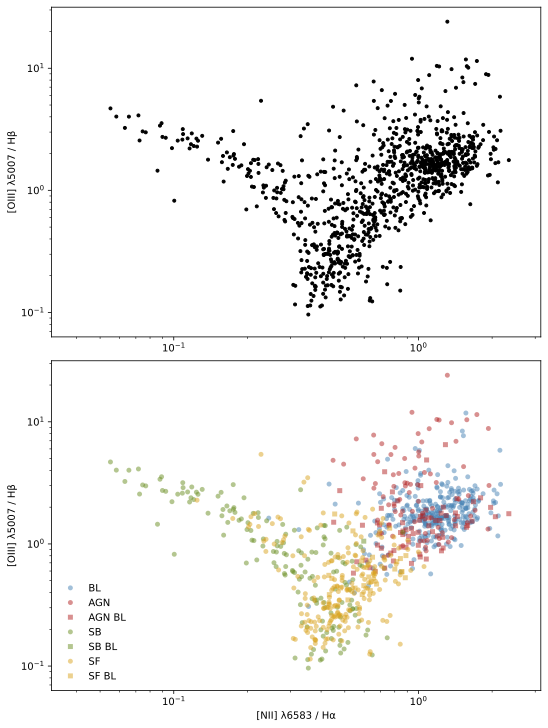

In [3]:
x_agn = df_tab[(df_tab['subclass'] == 'AGN')]['nii_halpha_ratio']
y_agn = df_tab[(df_tab['subclass'] == 'AGN')]['oiii_hbeta_ratio']

x_bl = df_tab[(df_tab['subclass'] == 'BROADLINE')]['nii_halpha_ratio']
y_bl = df_tab[(df_tab['subclass'] == 'BROADLINE')]['oiii_hbeta_ratio']

x_sb = df_tab[(df_tab['subclass'] == 'STARBURST')]['nii_halpha_ratio']
y_sb = df_tab[(df_tab['subclass'] == 'STARBURST')]['oiii_hbeta_ratio']

x_sf = df_tab[(df_tab['subclass'] == 'STARFORMING')]['nii_halpha_ratio']
y_sf = df_tab[(df_tab['subclass'] == 'STARFORMING')]['oiii_hbeta_ratio']

x_agn_bl = df_tab[(df_tab['subclass'] == 'AGN BROADLINE')]['nii_halpha_ratio']
y_agn_bl = df_tab[(df_tab['subclass'] == 'AGN BROADLINE')]['oiii_hbeta_ratio']

x_sb_bl = df_tab[(df_tab['subclass'] == 'STARBURST BROADLINE')]['nii_halpha_ratio']
y_sb_bl = df_tab[(df_tab['subclass'] == 'STARBURST BROADLINE')]['oiii_hbeta_ratio']

x_sf_bl = df_tab[(df_tab['subclass'] == 'STARFORMING BROADLINE')]['nii_halpha_ratio']
y_sf_bl = df_tab[(df_tab['subclass'] == 'STARFORMING BROADLINE')]['oiii_hbeta_ratio']

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10])

axs[0].plot(df_tab['nii_halpha_ratio'], df_tab['oiii_hbeta_ratio'], 'k.')

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlim(10**(-1.5), 10**(0.5))
axs[0].set_ylim(10**(-1.2), 10**(1.5))

axs[0].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].plot(x_bl, y_bl, '.', c='steelblue', mec='none', mew=0, ms=10, alpha=0.5, label='BL')

axs[1].plot(x_agn, y_agn, '.', c='firebrick', mec='none', mew=0, ms=10, alpha=0.5, label='AGN')
axs[1].plot(x_agn_bl, y_agn_bl, 's', c='firebrick', mec='none', mew=0, ms=5, alpha=0.5, label='AGN BL')

axs[1].plot(x_sb, y_sb, '.', c='olivedrab', mec='none', mew=0, ms=10, alpha=0.5, label='SB')
axs[1].plot(x_sb_bl, y_sb_bl, 's', c='olivedrab', mec='none', mew=0, ms=5, alpha=0.5, label='SB BL')

axs[1].plot(x_sf, y_sf, '.', c='goldenrod', mec='none', mew=0, ms=10, alpha=0.5, label='SF')
axs[1].plot(x_sf_bl, y_sf_bl, 's', c='goldenrod', mec='none', mew=0, ms=5, alpha=0.5, label='SF BL')

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend()

plt.show()
plt.close()

#### Kewley (2001)

$$\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) − 0.47} + 1.19$$

#### Kauffmann (2003)

$$\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) - 0.05} + 1.3$$

#### Schawinski (2007)

$$\log(\symup{[O III]}/\symup{Hβ}) = 1.05 \log(\symup{[N II]}/\symup{Hα}) + 0.45$$

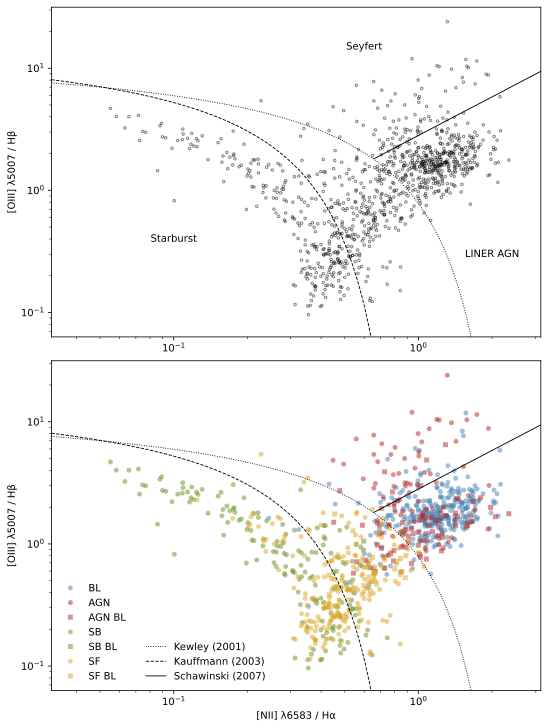

In [4]:
x = np.logspace(-1.5, 0.5, 400)

y_kewl = 10**(0.61 / (np.log10(x) - 0.47) + 1.19)
y_kewl = y_kewl[x < 10**(0.47)]
x_kewl = x[x < 10**(0.47)]

y_kauf = 10**(0.61 / (np.log10(x) - 0.05) + 1.3)
y_kauf = y_kauf[x < 10**(0.05)]
x_kauf = x[x < 10**(0.05)]

y_scha = 10**(1.05 * np.log10(x) + 0.45)
x_scha = x[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]
y_scha = y_scha[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]

fig, axs = plt.subplots(2, 1, figsize=[7.5, 10])

axs[0].plot(df_tab['nii_halpha_ratio'], df_tab['oiii_hbeta_ratio'], '.', mfc='none', mec='k', ms=5, alpha=0.5)

axs[0].plot(x_kewl, y_kewl, 'k:', lw=0.9)
axs[0].plot(x_kauf, y_kauf, 'k--', lw=0.9)
axs[0].plot(x_scha, y_scha, 'k-', lw=0.9)

axs[0].text(2, 0.3, 'LINER AGN', va='center', ha='center')
axs[0].text(0.6, 15, 'Seyfert', va='center', ha='center')
axs[0].text(0.1, 0.4, 'Starburst', va='center', ha='center')

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlim(10**(-1.5), 10**(0.5))
axs[0].set_ylim(10**(-1.2), 10**(1.5))

axs[0].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].plot(x_bl, y_bl, '.', c='steelblue', mec='none', mew=0, ms=10, alpha=0.5, label='BL')

axs[1].plot(x_agn, y_agn, '.', c='firebrick', mec='none', mew=0, ms=10, alpha=0.5, label='AGN')
axs[1].plot(x_agn_bl, y_agn_bl, 's', c='firebrick', mec='none', mew=0, ms=5, alpha=0.5, label='AGN BL')

axs[1].plot(x_sb, y_sb, '.', c='olivedrab', mec='none', mew=0, ms=10, alpha=0.5, label='SB')
axs[1].plot(x_sb_bl, y_sb_bl, 's', c='olivedrab', mec='none', mew=0, ms=5, alpha=0.5, label='SB BL')

axs[1].plot(x_sf, y_sf, '.', c='goldenrod', mec='none', mew=0, ms=10, alpha=0.5, label='SF')
axs[1].plot(x_sf_bl, y_sf_bl, 's', c='goldenrod', mec='none', mew=0, ms=5, alpha=0.5, label='SF BL')

axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')
axs[1].plot([], [], ' ', label=' ')

axs[1].plot(x_kewl, y_kewl, 'k:', lw=0.9, label='Kewley (2001)')
axs[1].plot(x_kauf, y_kauf, 'k--', lw=0.9, label='Kauffmann (2003)')
axs[1].plot(x_scha, y_scha, 'k-', lw=0.9, label='Schawinski (2007)')

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlim(10**(-1.5), 10**(0.5))
axs[1].set_ylim(10**(-1.2), 10**(1.5))

axs[1].set_xlabel('[NII] λ6583 / Hα')
axs[1].set_ylabel('[OIII] λ5007 / Hβ')

axs[1].legend(ncol=2)

plt.savefig('bpt.pdf')
plt.show()
plt.close()